In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

Lattice(400 vertices, 600 edges)


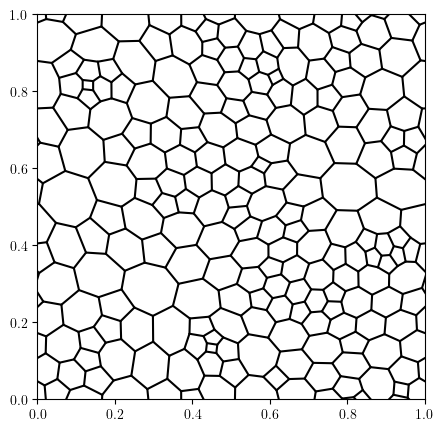

In [45]:
# generate the lattice and set the initial conditions

import koala.graph_utils


system_length = 20
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)


t1 = 1  # orbital parallel neighbor hopping
t2 = 0.1  # orbital perpendicular neighbor hopping
J = 0.3  # Interaction strength
U = J  # Density-density interaction
filling = 0.9  # filling of the lattice
initial_m = np.full(lattice.n_vertices, 1) + 0.001 * np.random.rand(lattice.n_vertices)
initial_n = np.full(lattice.n_vertices, filling * 4)
theta_offset = 0.0  # offset of the staggered magnetization
orbital_symmetry = 1

initial_parameters = {
    "t1": t1,
    "t2": t2,
    "J": J,
    "U": U,
    "filling": filling,
    "initial_m": initial_m,
    "initial_n": initial_n,
    "theta_offset": theta_offset,
}

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pl.plot_edges(lattice, ax=ax)
print(lattice)

In [46]:
from alter_morph.mean_field import hartree_fock

m_values, n_values = hartree_fock(
    lattice,
    initial_parameters,
    100,
    mixing_proportion=0.1,
    tol_mdiff=0.001,
    adjust_learning_rate=True,
    orbital_symmetry=orbital_symmetry,
)

  0%|          | 0/100 [00:00<?, ?it/s]

Avg:0.23, diff: 0.000595, zigzag: 36.0715, mix: 0.2995:  23%|██▎       | 23/100 [00:34<01:54,  1.49s/it]


In [17]:
hamiltonian = alt_hamiltonian(
    lattice,
    initial_parameters["t1"],
    initial_parameters["t2"],
    initial_parameters["J"],
    initial_parameters["U"],
    m_values[-1],
    n_values[-1],
    theta_offset=initial_parameters["theta_offset"],
    orbital_symmetry=orbital_symmetry,
)
energies, states = la.eigh(hamiltonian)

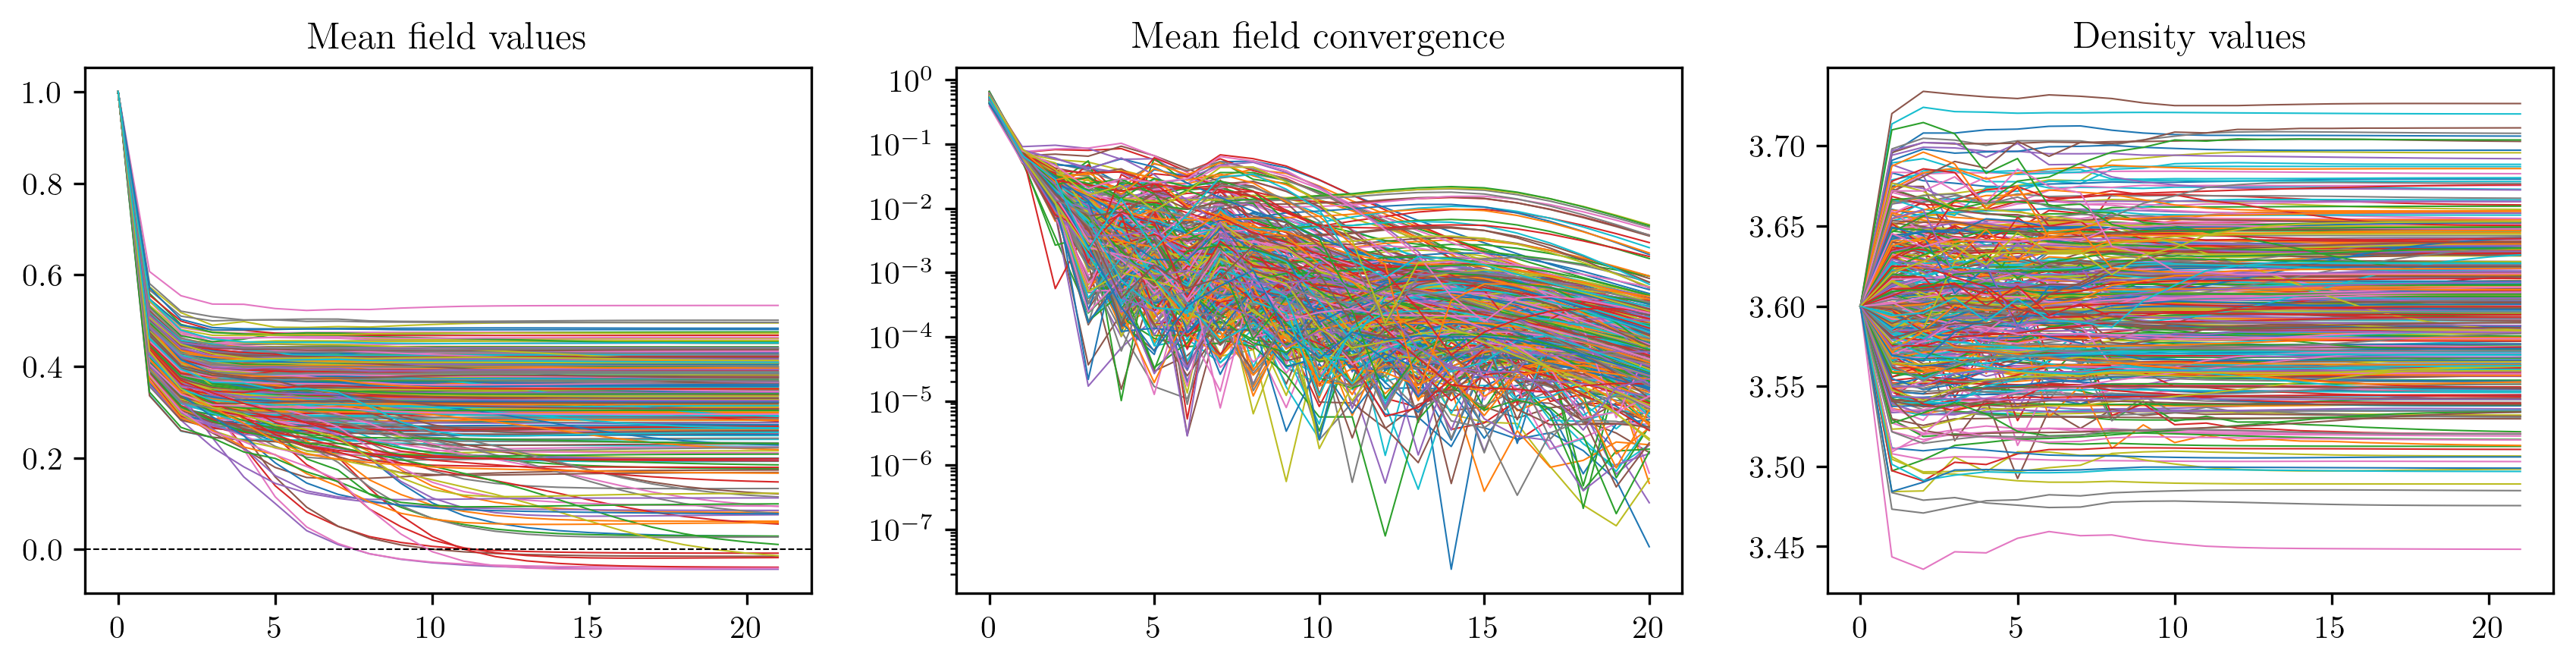

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3), dpi=300)
ax[0].plot(m_values, linewidth=0.5)
ax[0].axhline(0, linestyle="--", color="black", linewidth=0.5)

diffs = np.diff(m_values, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)

ax[2].plot(n_values, linewidth=0.5)


ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
ax[2].set_title("Density values")
plt.show()

In [44]:
fermi_occupation = np.linspace(0, 1, len(energies)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = energies[n_filled_states - 1]

real_space_occupation = fermi_occupation[None, :] * (states * states.conj())
average_occupation = np.sum(real_space_occupation, axis=1)
average_occupation = average_occupation.reshape(-1, 4).sum(axis=-1)

ipr = np.sum(states**4, axis=0)

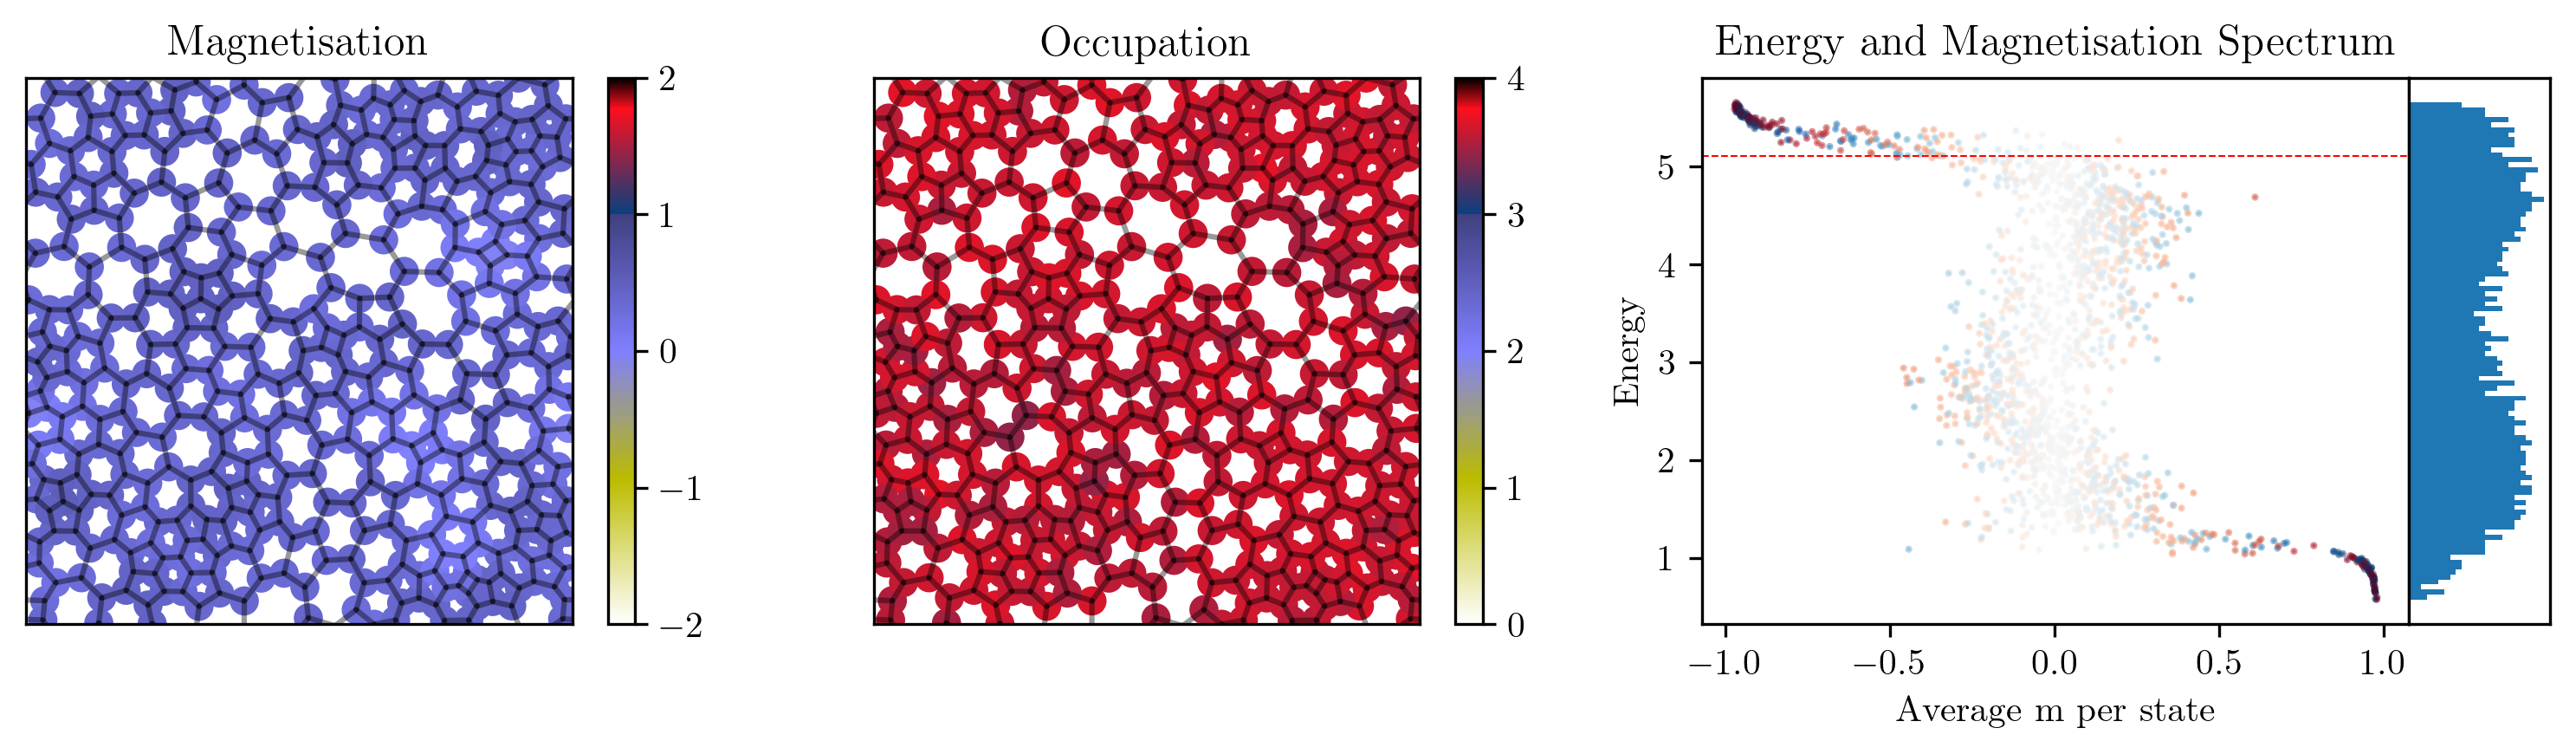

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)


average_m_per_state = find_m_per_state(states)
average_spin_per_state = find_spin_per_state(states)

m_values_out = m_values[-1]
if np.any(m_values_out < 0):
    m_vrange = [-2, 2]
else:
    m_vrange = [0, 2]

vertices = lattice.vertices.positions
pl.plot_edges(lattice, ax=ax[0], alpha=0.4)
im = ax[0].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=m_values_out,
    cmap="gist_stern_r",
    s=50,
    vmin=m_vrange[0],
    vmax=m_vrange[1],
)
plt.colorbar(im, ax=ax[0])
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Magnetisation")


pl.plot_edges(lattice, ax=ax[1], alpha=0.4)
im = ax[1].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=average_occupation,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=4,
)
plt.colorbar(im, ax=ax[1])
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Occupation")

im = ax[2].scatter(
    average_m_per_state, energies, s=1, c=average_spin_per_state, cmap="RdBu", alpha=0.5
)
ax[2].set_xlabel("Average m per state")
ax[2].set_ylabel("Energy")


ax_histy = ax[2].inset_axes([1.0, 0, 0.2, 1])
ax[2].axhline(fermi_energy, color="r", linestyle="--", linewidth=0.5)
ax[2].set_title("Energy and Magnetisation Spectrum")
# move ticks to left
ax[2].yaxis.tick_left()
# plt.colorbar(im, ax=ax[2], label="IPR",

ax_histy.hist(energies, bins=100, orientation="horizontal")
ax_histy.set_xticks([])
ax_histy.set_yticks([])

plt.tight_layout()

In [21]:
energy_to_look_at = fermi_energy
broadening = 0.5
specs = [
    spectral_function(
        lattice,
        energies,
        states,
        energy_to_look_at,
        local_operator=np.eye(4)[i],
        eta=broadening,
        n_k=50,
    )
    for i in range(4)
]

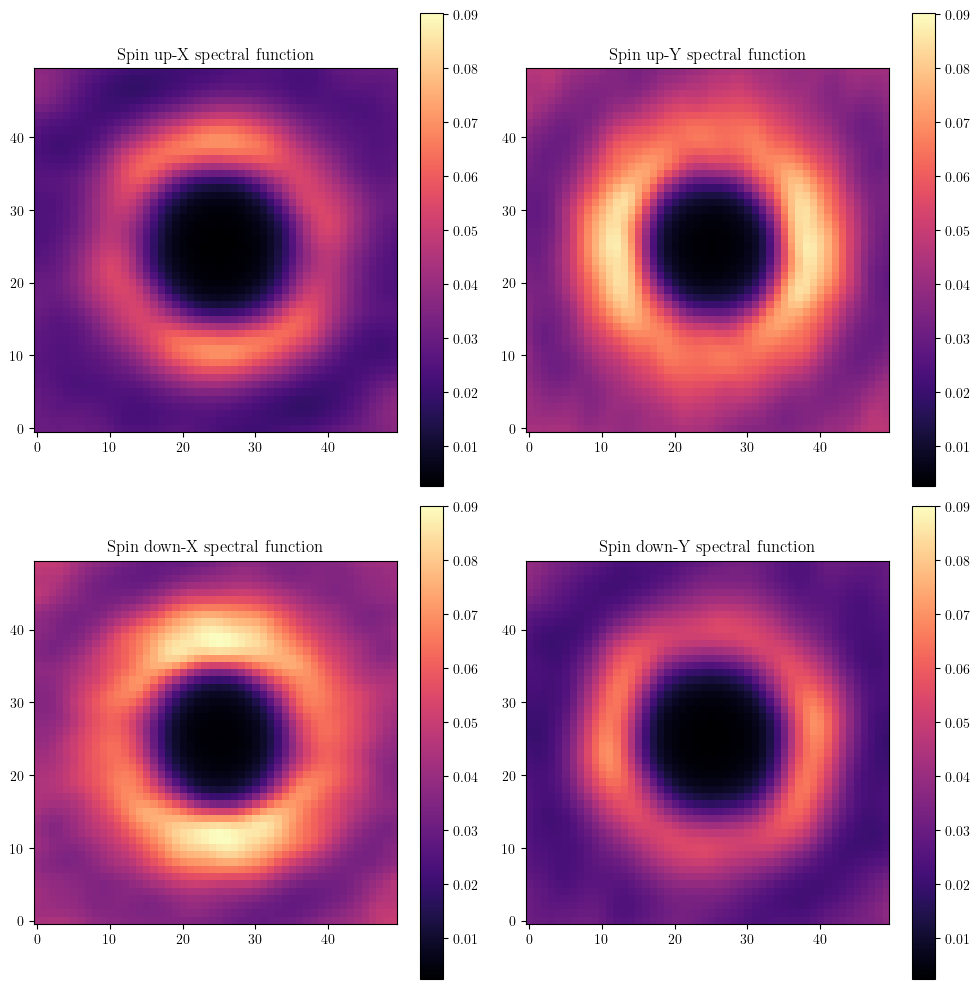

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
k_limits = 25

kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)

# log_specs = np.array([-spec.imag for spec in specs])

cmin = np.min(specs)
cmax = np.max(specs)

for n, a in enumerate(ax.flatten()):
    im = a.imshow(
        specs[n],
        cmap="magma",
        origin="lower",
        vmin=cmin,
        vmax=cmax,
    )
    # add colorbar
    plt.colorbar(im, ax=a)


ax[0, 0].set_title("Spin up-X spectral function")
ax[0, 1].set_title("Spin up-Y spectral function")
ax[1, 0].set_title("Spin down-X spectral function")
ax[1, 1].set_title("Spin down-Y spectral function")

# plt.savefig("mean_field_results.pdf")

plt.tight_layout()
plt.show()

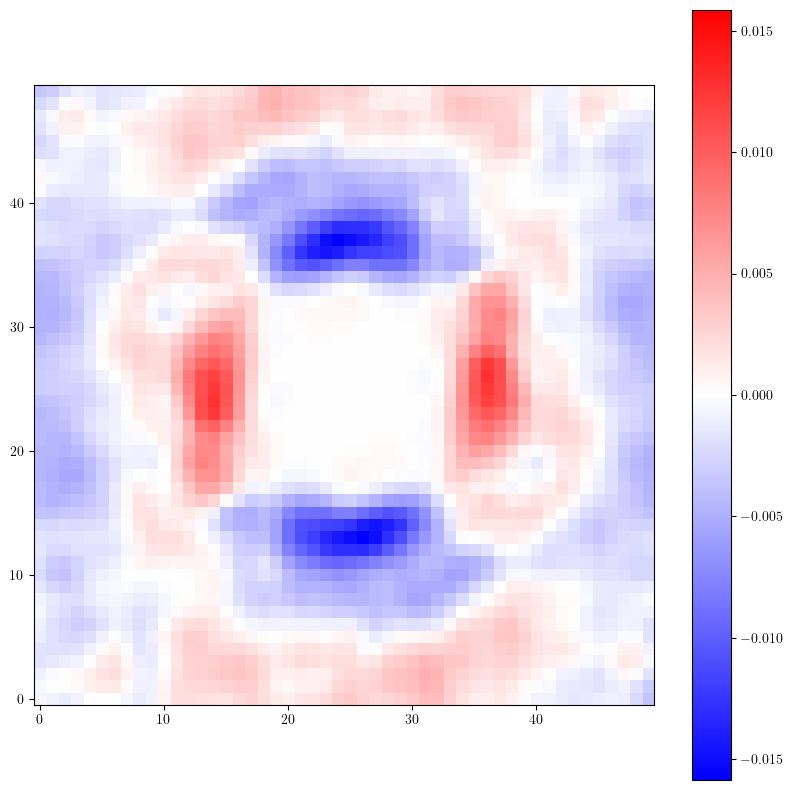

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
k_limits = 25
kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)


subtracted = specs[0] + specs[1] - specs[2] - specs[3]

max_val = np.max(np.abs(subtracted))

im = ax.imshow(
    subtracted,
    cmap="bwr",
    origin="lower",
    vmin=-max_val,
    vmax=max_val,
)

plt.colorbar(im, ax=ax)

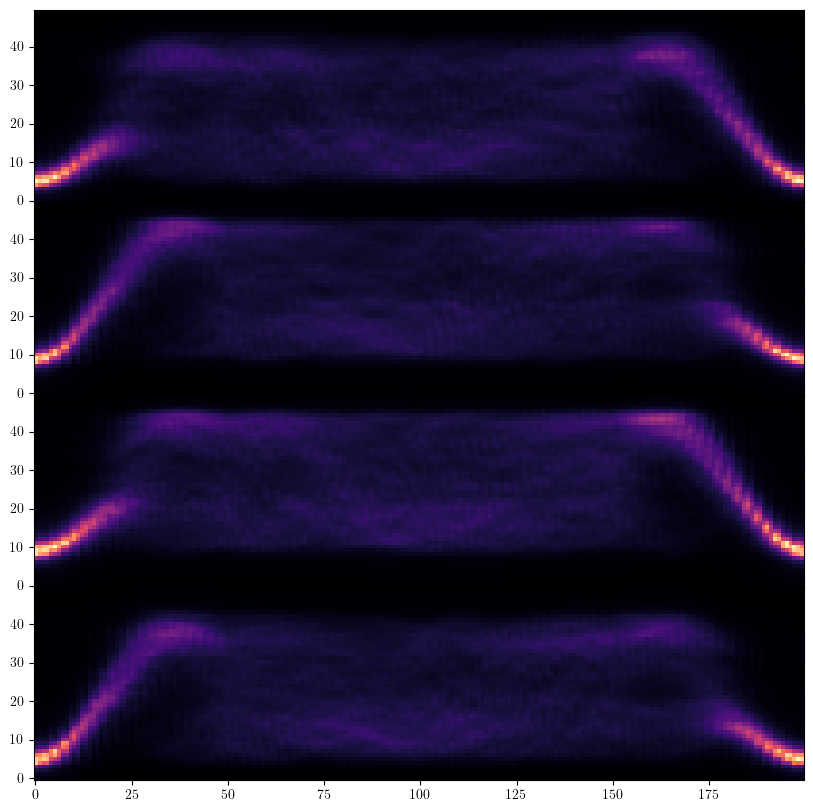

In [24]:
from alter_morph.hamiltonians import spectral_path

n_k = 50
n_e = 50
paths = specs = [
    spectral_path(
        lattice,
        energies,
        states,
        0.1,
        n_k=n_k,
        n_energy=n_e,
        local_operator=np.eye(4)[i],
    )
    for i in range(4)
]

fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
fig.subplots_adjust(hspace=0.0)
for i in range(4):
    ax[i].imshow(paths[i].T, cmap="magma", origin="lower")